## Function 2
#Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. 
#Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum.
#To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. 
#It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.


In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

# 1. Load 8D spatial coordinate data and output values
inputs = np.load('/home/mcevoyj777/_CAPSTONE/FUNC2/initial_inputs.npy')
output = np.load('/home/mcevoyj777/_CAPSTONE/FUNC2/initial_outputs.npy')
print(output.max())
extra_inputs = [[0.665657, 0.285859],[0.000001, 0.999999],[0.000000, 0.400000],[0.873475, 1.000000],
                [0.804203, 0.167947],[0.700531, 0.998469],[0.735062, 0.932771],	[0.702637, 0.926564]]
extra_output = [0.3700855557672495,-0.04250067518679212,-0.04577773915272362,-0.0016845126456047164,
                0.14065256824649874,0.5200799191934261,0.36682621269052196,0.6168419402238136]

inputs = np.vstack([inputs, extra_inputs])
output = np.append(output, extra_output)

print(output.max())
print(inputs)
print(output)
print("Inputs shape:", inputs.shape)
print("Output shape:", output.shape)
print("Inputs type:", type(inputs))
print("Output type:", type(output))

# 2. Combine into a single Pandas DataFrame
df = pd.DataFrame(inputs, columns=['Input_Y', 'Input_Z'])
df['Output_Target'] = output

# 3. Compute the correlation matrix
# Change method to 'spearman' if relationships are non-linear curves
corr_matrix = df.corr(method='pearson')

# 4. Isolate how each input correlates *only* with the target output
target_corr = corr_matrix['Output_Target'].drop('Output_Target')

print("Correlation with Output:")
print(target_corr)

# Calculate non-linear relationship dependency (higher score = stronger relationship)
mi_scores = mutual_info_regression(inputs, output)

for name, score in zip(['Input_Y', 'Input_Z'], mi_scores):
    print(f"{name} Mutual Information Score: {score:.4f}")


# Fit a quick non-linear model that checks all 2 dimensions simultaneously
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(inputs, output)

# Extract total feature importances (including interactions)
importances = model.feature_importances_

for name, score in zip(['Input_Y','Input_Z'], importances):
    print(f"{name} Total Importance (with interactions): {score:.4f}")

# Setup

0.6112052157614438
0.6168419402238136
[[6.65799580e-01 1.23969128e-01]
 [8.77790989e-01 7.78627501e-01]
 [1.42699074e-01 3.49005131e-01]
 [8.45275429e-01 7.11120267e-01]
 [4.54647141e-01 2.90455180e-01]
 [5.77712844e-01 7.71973184e-01]
 [4.38166062e-01 6.85018257e-01]
 [3.41749593e-01 2.86977198e-02]
 [3.38648157e-01 2.13867246e-01]
 [7.02636557e-01 9.26564198e-01]
 [6.65657000e-01 2.85859000e-01]
 [1.00000000e-06 9.99999000e-01]
 [0.00000000e+00 4.00000000e-01]
 [8.73475000e-01 1.00000000e+00]
 [8.04203000e-01 1.67947000e-01]
 [7.00531000e-01 9.98469000e-01]
 [7.35062000e-01 9.32771000e-01]
 [7.02637000e-01 9.26564000e-01]]
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.37008556 -0.04250068
 -0.04577774 -0.00168451  0.14065257  0.52007992  0.36682621  0.61684194]
Inputs shape: (18, 2)
Output shape: (18,)
Inputs type: <class 'numpy.ndarray'>
Output type: <class 'numpy.ndarray'>
Correlation with Output:
Input_

In [2]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Train a predictive model on your 20 existing samples
predictor = RandomForestRegressor(n_estimators=100, random_state=42)
predictor.fit(inputs, output)

def objective_2D(X):
    """
    Surrogate function for 4D optimization.
    X: A 2D numpy array of shape (n_samples, 4) sent by the optimizer.
    """
    # Force input to be 2D array matrix for sklearn compatibility
    X = np.atleast_2d(X)
    
    # Predict the output value using the trained model
    predictions = predictor.predict(X)
    
    # Return as a flat 1D array as expected by your code (.ravel())
    return predictions.ravel()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern
from scipy.stats import norm
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

def upper_confidence_bound(mu, sigma, kappa=0.1):
    """
    Upper Confidence Bound (UCB) acquisition function.
    
    UCB = mean + kappa * std
    
    Parameters:
    -----------
    mu : predicted mean
    sigma : predicted standard deviation
    kappa : exploration parameter (higher = more exploration)
    """
    return mu + kappa * sigma

def expected_improvement(mu, sigma, y_best, xi=0.01):
    """
    Expected Improvement (EI) acquisition function.
    
    EI = E[max(f(x) - f(x_best), 0)]
    
    Parameters:
    -----------
    mu : predicted mean
    sigma : predicted standard deviation  
    y_best : best observed value so far
    xi : exploration parameter
    """
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

In [4]:
def bayesian_optimization_nd(objective_func, n_dims, n_iterations=1, 
                            n_initial=1, acquisition='ei'):
    """
    Bayesian Optimization for n-dimensional functions.
    Assumes bounds [0, 1] for all dimensions.
    """
    bounds = [(0, 1) for _ in range(n_dims)]
    
    # Initialize
    X_samples = inputs
    y_samples = output
    
    
    best_values = [y_samples.max()]
    
    print(f"Starting {n_dims}D optimization with {n_initial} initial samples...")
    print(f"Initial best: {y_samples.max():.4f}\n")
  
    
    for iteration in range(n_iterations):
        # Fit GP
        kernel = ConstantKernel(1.0) * Matern(length_scale=0.3,nu=2.0)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,normalize_y=True,
                                     n_restarts_optimizer=5)
        gp.fit(X_samples, y_samples)

        # Optimize acquisition function
        def acq_objective(X):
            X = X.reshape(1, -1)
            mu, sigma = gp.predict(X, return_std=True)
            
            if acquisition == 'ei':
                acq_val = expected_improvement(mu, sigma, y_samples.max())
            else:
                acq_val = upper_confidence_bound(mu, sigma, kappa=1)
           
            return -acq_val
        
        # Multi-start optimization
        best_acq = np.inf
        X_next = None
        
        for _ in range(30):  # More starts for higher dimensions
            x0 = np.random.uniform(0, 1, n_dims)
            result = minimize(acq_objective, x0, bounds=bounds, method='L-BFGS-B')
            if result.fun < best_acq:
                best_acq = result.fun
                X_next = result.x
                print(f"Optimized Next Point Found! Predicted Acquisition Score: {-best_acq:.6f}")
                print(f"Coordinates to test next: {X_next}")

       
        # Evaluate
        y_next = objective_func(X_next.reshape(1, -1)).ravel()
        
        # Update
        X_samples = np.vstack([X_samples, X_next])
        y_samples = np.append(y_samples, y_next)
        best_values.append(y_samples.max())
        
        if (iteration + 1) % 10 == 0:
            print(f"Iteration {iteration + 1}: Best f(x)={y_samples.max():.4f}")
    
    return X_samples, y_samples, best_values



# Run 6D optimization
X_samples_2d, y_samples_2d, best_values_2d = bayesian_optimization_nd(
    objective_2D, 
    n_dims=2,
    n_iterations=5,
    acquisition='ei'
)

Starting 2D optimization with 1 initial samples...
Initial best: 0.6168

Optimized Next Point Found! Predicted Acquisition Score: 0.003175
Coordinates to test next: [0.65447075 0.95795175]
Optimized Next Point Found! Predicted Acquisition Score: 0.003968
Coordinates to test next: [0.42644397 0.28732584]
Optimized Next Point Found! Predicted Acquisition Score: 0.003390
Coordinates to test next: [0.89976294 0.64598532]
Optimized Next Point Found! Predicted Acquisition Score: 0.003012
Coordinates to test next: [0.84125346 0.40256294]
Optimized Next Point Found! Predicted Acquisition Score: 0.002644
Coordinates to test next: [0.63110936 0.23204988]


[6.65799580e-01 8.77790989e-01 1.42699074e-01 8.45275429e-01
 4.54647141e-01 5.77712844e-01 4.38166062e-01 3.41749593e-01
 3.38648157e-01 7.02636557e-01 6.65657000e-01 1.00000000e-06
 0.00000000e+00 8.73475000e-01 8.04203000e-01 7.00531000e-01
 7.35062000e-01 7.02637000e-01] [0.12396913 0.7786275  0.34900513 0.71112027 0.29045518 0.77197318
 0.68501826 0.02869772 0.21386725 0.9265642  0.285859   0.999999
 0.4        1.         0.167947   0.998469   0.932771   0.926564  ]
🎯 Recommended Point to Sample Next (Highest Variance Focus): [1.         0.44444444]


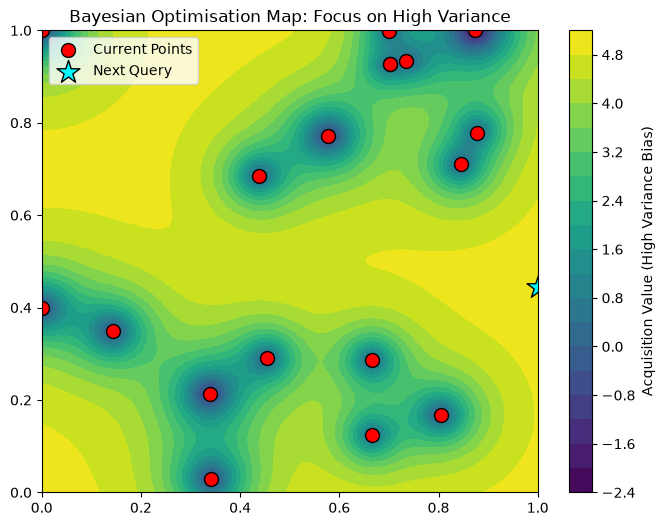

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

x = inputs[:, 0]
y = inputs[:, 1]


print(x,y)



# 2. Critical Step: Log-Transform the Target Space
# Takes absolute values and floors extremely tiny values to prevent log(-inf) issues.
y_clean = np.abs(output)
floor = 1e-30
y_clean = np.where(y_clean < floor, floor, y_clean)
y_log = np.log10(y_clean)

# 3. Fit the Gaussian Process Regressor
# A Matérn kernel allows the model to capture sharp, localized spikes.
kernel = Matern(length_scale=[0.1, 0.1], length_scale_bounds="fixed")
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5, n_restarts_optimizer=20)
gp.fit(inputs, y_log)

# 4. Define a High-Variance (Exploratory) Acquisition Function
def high_variance_ucb(X_grid, gp_model, beta=10.0):
    """
    Acquisition Function: UCB = Mean + beta * Standard Deviation
    Setting beta high (e.g., 5.0 to 20.0) forces the search to focus on 
    high-variance unmapped zones rather than exploiting existing peaks.
    """
    mean, std = gp_model.predict(X_grid, return_std=True)
    return mean + (beta * std)

# 5. Generate a dense grid to scan for the next query coordinate
x_span = np.linspace(0.0, 1, 100)
y_span = np.linspace(0.0, 1, 100)
X_mesh, Y_mesh = np.meshgrid(x_span, y_span)
grid_points = np.c_[X_mesh.ravel(), Y_mesh.ravel()]

# Evaluate acquisition values across the entire map
acq_values = high_variance_ucb(grid_points, gp, beta=5.0)
acq_grid = acq_values.reshape(X_mesh.shape)

# Find the absolute best coordinate point to sample next
best_idx = np.argmax(acq_values)
next_query_point = grid_points[best_idx]

print(f"🎯 Recommended Point to Sample Next (Highest Variance Focus): {next_query_point}")

# 6. Optional: Visualize the acquisition field map
plt.figure(figsize=(8, 6))
plt.contourf(X_mesh, Y_mesh, acq_grid, cmap='viridis', levels=20)
plt.colorbar(label='Acquisition Value (High Variance Bias)')
plt.scatter(inputs[:, 0], inputs[:, 1], color='red', edgecolor='black', s=100, label='Current Points')
plt.scatter(next_query_point[0], next_query_point[1], color='cyan', marker='*', s=300, edgecolor='black', label='Next Query')
plt.legend()
plt.title("Bayesian Optimisation Map: Focus on High Variance")
plt.show()

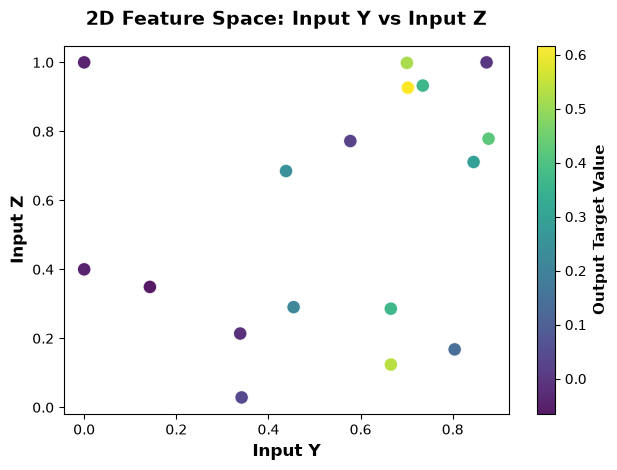

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Create scatter plot with a continuous color mapping (viridis)
scatter = plt.scatter(
    data=df, 
    x='Input_Y', 
    y='Input_Z', 
    c='Output_Target', 
    cmap='viridis', 
    s=100,            # Marker size
    edgecolor='w',    # White border around markers
    alpha=0.9
)

# Add elements
cbar = plt.colorbar(scatter)
cbar.set_label('Output Target Value', fontsize=11, fontweight='bold')
plt.xlabel('Input Y', fontsize=12, fontweight='bold')
plt.ylabel('Input Z', fontsize=12, fontweight='bold')
plt.title('2D Feature Space: Input Y vs Input Z', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

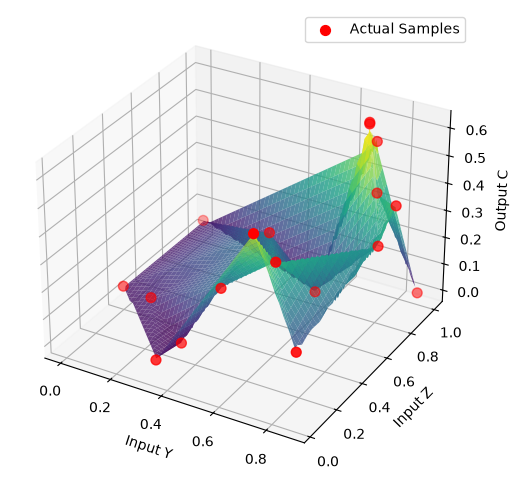

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

# 1. Your 10 matching sample vectors
a = inputs[:, 0]
b = inputs[:, 1]
c = y_clean

# 2. Generate a dense grid boundary over your data range
a_dense = np.linspace(a.min(), a.max(), 100)
b_dense = np.linspace(b.min(), b.max(), 100)
A, B = np.meshgrid(a_dense, b_dense)

# 3. Estimate missing grid data (linear or cubic interpolation)
# Points outside the boundary polygon of your 10 points will return NaN
C = griddata((a, b), c, (A, B), method='linear')

# 4. Render the predicted surface
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
surf = ax.plot_surface(A, B, C, cmap='viridis', edgecolor='none', alpha=0.8)

# 5. Optional: Overlay your original 10 points to verify accuracy
ax.scatter(a, b, c, color='red', s=50, label='Actual Samples')

ax.set_xlabel('Input Y')
ax.set_ylabel('Input Z')
ax.set_zlabel('Output C')
plt.legend()
plt.show()

In [12]:
import torch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.acquisition import qLogExpectedImprovement
from botorch.optim import optimize_acqf


# 2. Optimization Settings
DIM = 2
N_INIT = 5          # Number of initial random evaluations
N_ITERATIONS = 5    # Number of Bayesian Optimization rounds
BATCH_SIZE = 1      # Evaluate 1 point at a time

# Bounds for tensor
bounds = torch.tensor([[0.0, 0.0], [1.0, 1.0]], dtype=torch.double)

# 3. Generate initial training data
train_X = torch.tensor(inputs, dtype=torch.double)      # Shape: (N, 2)
train_Y = torch.tensor(output, dtype=torch.double).unsqueeze(-1)  # Shape: (N, 1)

print(f"Initial best observed value: {train_Y.max().item():.4f}")

# 4. Main Bayesian Optimization Loop
for i in range(N_ITERATIONS):
    # Standardize outputs to help the GP fit better
    standardized_Y = (train_Y - train_Y.mean()) / train_Y.std()
    
    # Fit the Gaussian Process model
    # SingleTaskGP automatically infers and adds a Gaussian noise kernel (Homoskedastic)
    gp = SingleTaskGP(train_X, standardized_Y)
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_mll(mll)
    
    # Define Expected Improvement acquisition function
    # xi=0.1 adds a jitter parameter to heavily encourage exploration over exploitation
    acq_func = qLogExpectedImprovement(
        model=gp,
        best_f=standardized_Y.max(),
       
    )
    
    # Optimize the acquisition function to find the next best inputs
    new_X, acq_value = optimize_acqf(
        acq_function=acq_func,
        bounds=bounds,
        q=BATCH_SIZE,
        num_restarts=10,
        raw_samples=50,
    )
    
    
    
    print(f"Iteration {i+1}/{N_ITERATIONS} | Best Value: {train_Y.max().item():.4f} | Next Point: {new_X.numpy()[0]}")

# 5. Final Results
best_idx = train_Y.argmax()
print("\n--- Optimization Complete ---")
print(f"Best Input Coordinates: {train_X[best_idx].numpy()}")
print(f"Best Noisy Log-Likelihood Score: {train_Y[best_idx].item():.4f}")

Initial best observed value: 0.6168
Iteration 1/5 | Best Value: 0.6168 | Next Point: [0.68644784 0.86956449]
Iteration 2/5 | Best Value: 0.6168 | Next Point: [0.68645197 0.86957292]
Iteration 3/5 | Best Value: 0.6168 | Next Point: [0.68645463 0.86957839]
Iteration 4/5 | Best Value: 0.6168 | Next Point: [0.68643376 0.86953574]
Iteration 5/5 | Best Value: 0.6168 | Next Point: [0.68637239 0.8694107 ]

--- Optimization Complete ---
Best Input Coordinates: [0.702637 0.926564]
Best Noisy Log-Likelihood Score: 0.6168
